In [38]:
#IMPORT ALL LIBRARIES
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
import ipywidgets as widgets
from IPython.display import display

A_id: Unique identifier for each fruit
Size: Size of the fruit
Weight: Weight of the fruit
Sweetness: Degree of sweetness of the fruit
Crunchiness: Texture indicating the crunchiness of the fruit
Juiciness: Level of juiciness of the fruit
Ripeness: Stage of ripeness of the fruit
Acidity: Acidity level of the fruit
Quality: Overall quality of the fruit

In [39]:
# Load data from CSV
df = pd.read_csv('apple_quality.csv')

print(df.head())

   A_id      Size    Weight  Sweetness  Crunchiness  Juiciness  Ripeness  \
0     0 -3.970049 -2.512336   5.346330    -1.012009   1.844900  0.329840   
1     1 -1.195217 -2.839257   3.664059     1.588232   0.853286  0.867530   
2     2 -0.292024 -1.351282  -1.738429    -0.342616   2.838636 -0.038033   
3     3 -0.657196 -2.271627   1.324874    -0.097875   3.637970 -3.413761   
4     4  1.364217 -1.296612  -0.384658    -0.553006   3.030874 -1.303849   

    Acidity Quality  
0 -0.491590    good  
1 -0.722809    good  
2  2.621636     bad  
3  0.790723    good  
4  0.501984    good  


In [40]:
print(df.columns)

Index(['A_id', 'Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness',
       'Ripeness', 'Acidity', 'Quality'],
      dtype='object')


In [41]:
# Check for null values in the DataFrame
null_values = df.isnull().sum()

# Display the null values
print("Null Values in the DataFrame:")
print(null_values)

Null Values in the DataFrame:
A_id           0
Size           0
Weight         0
Sweetness      0
Crunchiness    0
Juiciness      0
Ripeness       0
Acidity        0
Quality        0
dtype: int64


In [42]:
# Assuming 'Quality' is the name of your target column
df['Quality'] = df['Quality'].map({'good': 1, 'bad': 0})

# Now 'good' will be replaced with 1 and 'bad' with 0
print(df['Quality'].value_counts())

1    2004
0    1996
Name: Quality, dtype: int64


In [43]:
# Calculate Pearson correlation coefficients
correlation_matrix = df.corr()
correlation_with_target = correlation_matrix['Quality'].sort_values(ascending=False)

# Display Pearson correlation coefficients
print("Pearson Correlation Coefficients:")
print(correlation_with_target)

Pearson Correlation Coefficients:
Quality        1.000000
Juiciness      0.260223
Sweetness      0.250998
Size           0.244007
A_id           0.004875
Weight         0.001421
Acidity       -0.007697
Crunchiness   -0.012376
Ripeness      -0.264315
Name: Quality, dtype: float64


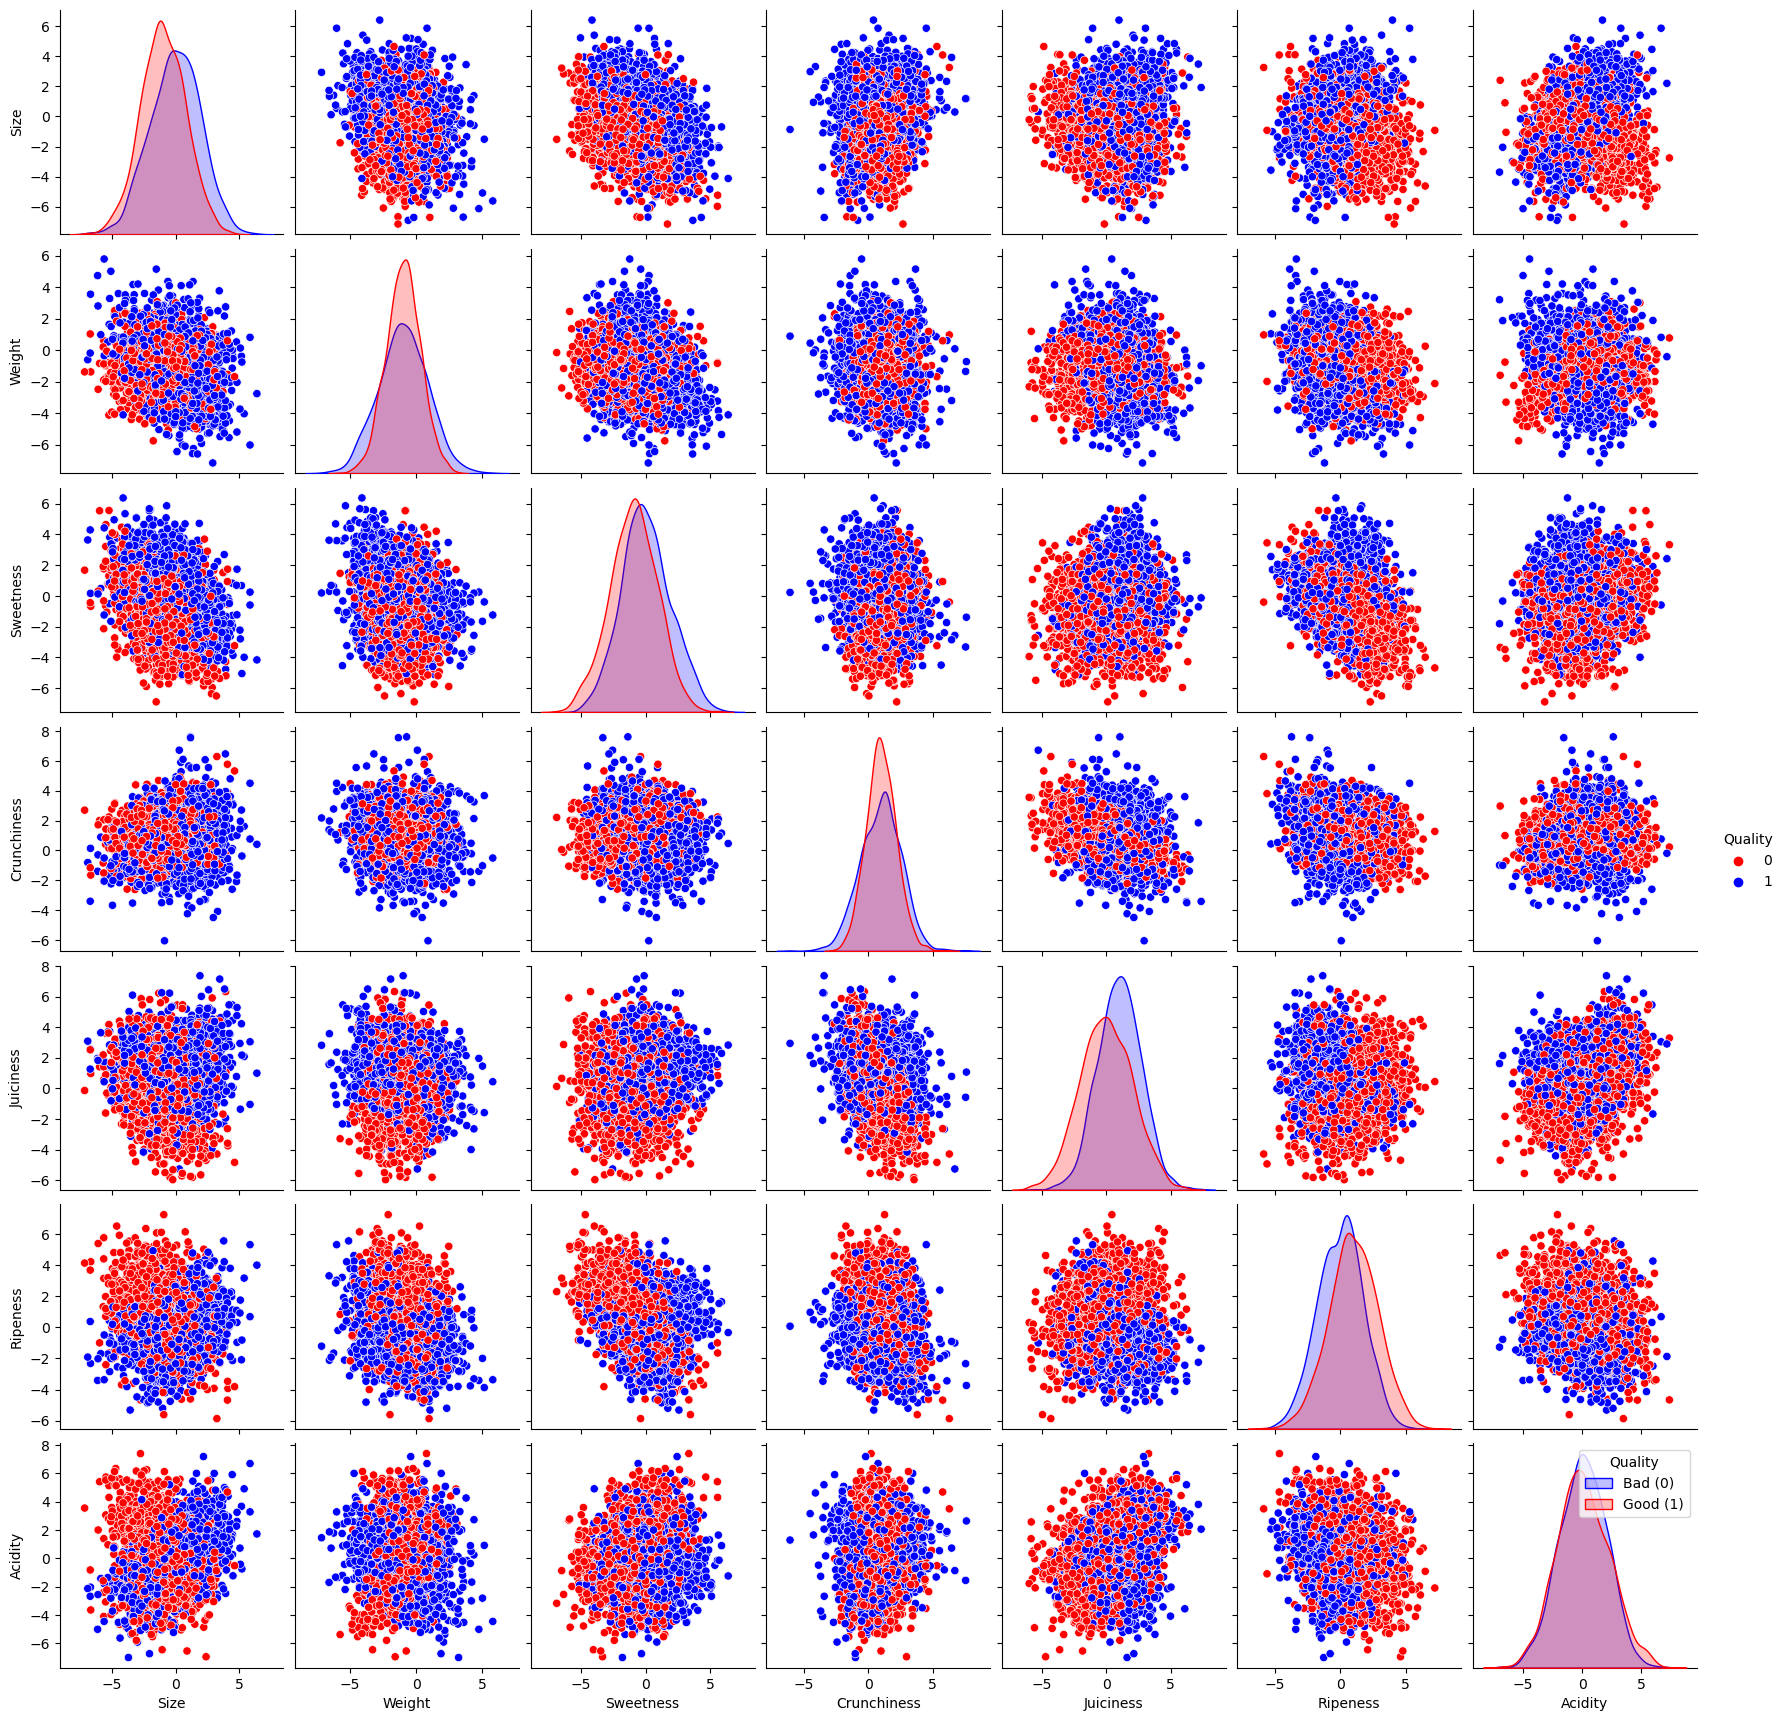

In [45]:
# Select relevant columns for the pairplot
selected_columns = ['Quality','Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness', 'Ripeness', 'Acidity']

# Set custom colors for the hue categories
hue_colors = {0: 'red', 1: 'blue'}

# Create pairplot with hue and custom colors
sns.pairplot(df[selected_columns], hue='Quality', palette=hue_colors)
plt.legend(title='Quality', labels=['Bad (0)', 'Good (1)'])
plt.show()

These variables show a moderate linear relationship with the target variable 'Quality'. 
Positive Correlations:

Juiciness: 0.260223
Sweetness: 0.250998
Size: 0.244007
    
Negative Correlations:

Ripeness: -0.264315

In [ ]:
# Assuming df is your DataFrame with the data
X = df[['Juiciness', 'Sweetness', 'Size', 'Ripeness']]
y = df['Quality']

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Build a simple neural network model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # binary classification

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test))

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Convert probabilities to binary predictions (0 or 1)
y_pred_binary = (y_pred > 0.5).astype(int)

# If lengths don't match, adjust y_pred_binary
if len(y_test) < len(y_pred_binary):
    y_pred_binary = y_pred_binary[:-1]  # Remove the last element of y_pred_binary

# Now, check the lengths again
print(len(y_test), len(y_pred_binary))

# Calculate binary classification metrics
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
f1 = f1_score(y_test, y_pred_binary)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_binary)
print('Confusion Matrix:')
print(conf_matrix)


In [ ]:
# Replace NaN values in y_pred with a specific value (e.g., 0.5)
y_pred = np.nan_to_num(y_pred, nan=0.5)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
#3A
def predict_quality():
    # Get user input for each feature
    juiciness = float(input("Enter Juiciness value: "))
    sweetness = float(input("Enter Sweetness value: "))
    size = float(input("Enter Size value: "))
    ripeness = float(input("Enter Ripeness value: "))

    # Standardize user inputs
    user_input_scaled = scaler.transform([[juiciness, sweetness, size, ripeness]])

    # Make prediction
    prediction = model.predict(user_input_scaled)

    # Display the predicted quality
    print(" ")
    print(f'Predicted Quality: {prediction[0, 0]}')

In [ ]:
predict_quality()

In [ ]:
#3A
# Create input widgets for each feature
juiciness_widget = widgets.FloatSlider(min=-3, max=3, step=0.1, description='Juiciness:')
sweetness_widget = widgets.FloatSlider(min=-3, max=3, step=0.1, description='Sweetness:')
size_widget = widgets.FloatSlider(min=-3, max=3, step=0.1, description='Size:')
ripeness_widget = widgets.FloatSlider(min=-3, max=3, step=0.1, description='Ripeness:')

# Create a button widget
predict_button = widgets.Button(description="Predict Quality")

# Output widget to display the prediction
output = widgets.Output()

# Function to be called on button click
def on_predict_button_click(b):
    with output:
        output.clear_output()
        juiciness = juiciness_widget.value
        sweetness = sweetness_widget.value
        size = size_widget.value
        ripeness = ripeness_widget.value

        # Standardize user inputs
        user_input_scaled = scaler.transform([[juiciness, sweetness, size, ripeness]])

        # Make prediction
        prediction = model.predict(user_input_scaled)

        # Display the predicted quality
        print(f'Predicted Quality: {prediction[0, 0]}')

# Attach the function to the button's click event
predict_button.on_click(on_predict_button_click)

# Display the widgets
display(juiciness_widget, sweetness_widget, size_widget, ripeness_widget, predict_button, output)